## Import all the necessary config files

In [1]:
#is python selected as the kernel?
#have you closed the parameters excel sheet?

from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)

#if you get an error here you propoably didn't close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'A1 Myrmidon base condition 25112025'

## Run the coral model

## Run simulation for n number of times and plot the total coral cover

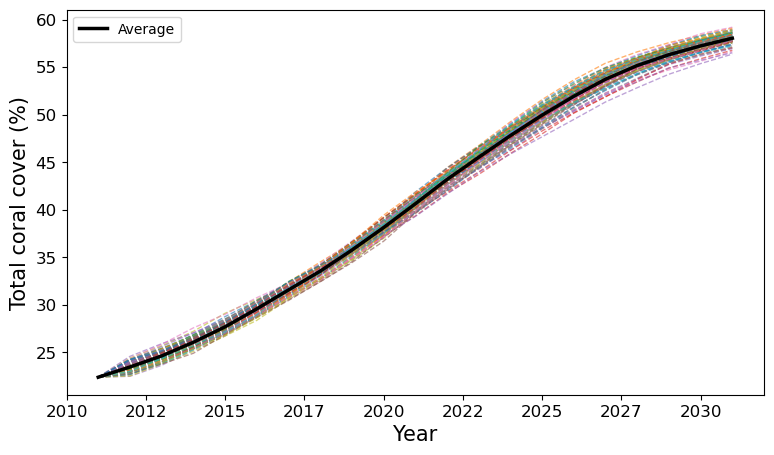

In [3]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

## Run the model through a number iterations for all parameters and export results

In [4]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.000000          2.100000       18.300000   
1      1            2.085822          2.321441       18.802628   
2      2            2.359929          2.489123       19.574086   
3      3            2.837238          2.662500       20.185715   
4      4            3.442606          2.836073       21.141053   
..   ...                 ...               ...             ...   
16    16           27.187932          3.830681       23.302665   
17    17           28.916201          3.836474       23.032194   
18    18           30.514682          3.807119       22.562722   
19    19           31.903266          3.776980       22.322685   
20    20           33.077240          3.746546       22.013434   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               22.400000                80.400000                66.000000   
1               23.209891        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

In [5]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)


=== sediment_df ===


,Year,Month,Suspended_sediment,Deposited_sediment
0,2011,1,0,0
1,2011,2,0,0
2,2011,3,0,0
3,2011,4,0,0
4,2011,5,0,0



=== sediment_years ===
NOT FOUND

=== add_sedi_exp_per_year ===
{0: (0.0, 0.0),
 1: (0.0, 0.0),
 2: (0.0, 0.0),
 3: (0.0, 0.0),
 4: (0.0, 0.0),
 5: (0.0, 0.0),
 6: (0.0, 0.0),
 7: (0.0, 0.0),
 8: (0.0, 0.0),
 9: (0.0, 0.0),
 10: (0.0, 0.0),
 11: (0.0, 0.0),
 12: (0.0, 0.0),
 13: (0.0, 0.0),
 14: (0.0, 0.0),
 15: (0.0, 0.0),
 16: (0.0, 0.0),
 17: (0.0, 0.0),
 18: (0.0, 0.0),
 19: (0.0, 0.0),
 20: (0.0, 0.0)}

=== suspended ===
0.0

=== deposited ===
0.0

=== sedi_exp_growth_coeff ===
{'Branching': -0.00997, 'Foliose': -0.00272, 'Other': -0.00533}

=== sedi_exp_PCM_coeff ===
{'Branching': 0.00154, 'Foliose': 0.000724, 'Other': 0.001645}


Saved figures to: output/figures as A1 Myrmidon base condition 25112025_1x4_nobasel.png/.pdf/.svg


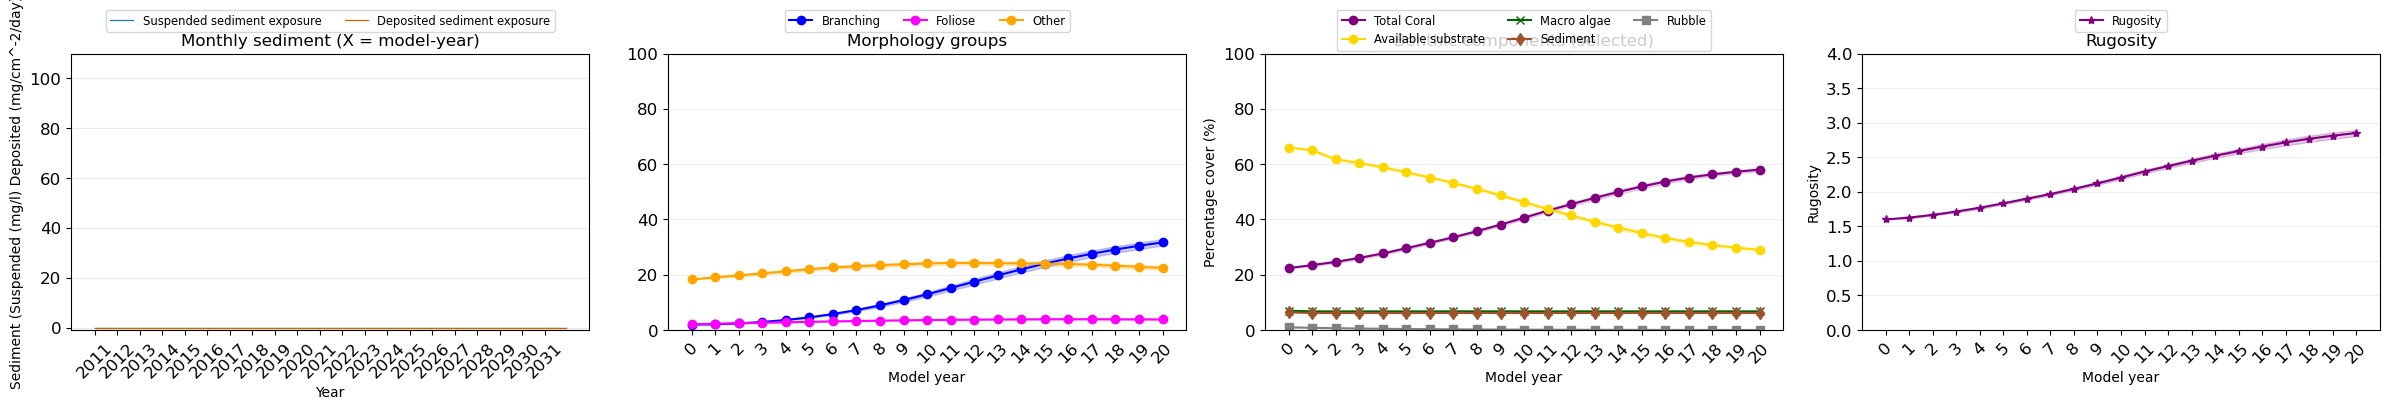

In [6]:
#plot above with real
#Version with new labels like those in Nikkis paper 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

MaxYear = int(globals().get('MaxYear', 20))
year_start = int(globals().get('year_start', 0))

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

model_x = np.arange(0, MaxYear + 1)
actual_years = model_x + year_start

fig, axs = plt.subplots(1, 4, figsize=(24, 5), sharey=False)
# ensure axs is iterable when ncols==1
if not hasattr(axs, "__iter__"):
    axs = [axs]

# --- Plot 1: Monthly sediment (X = model-year with month offset) ---
ax = axs[0]
sedi_src = globals().get('sedi_years', {}) or globals().get('sediment_df', {})
#baseline_suspended = float(globals().get('baseline_suspended_sediment', 0))
#baseline_deposited = float(globals().get('baseline_deposited_sediment', 0))

pts = []
if isinstance(sedi_src, dict):
    for k, v in sedi_src.items():
        try:
            if isinstance(k, (tuple, list)) and len(k) >= 2:
                ry = int(k[0]); m = int(k[1])
            else:
                continue
            if isinstance(v, (list, tuple)) and len(v) >= 2:
                suspended = float(v[0]); deposited = float(v[1])
            elif isinstance(v, dict):
                suspended = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                deposited = float(v.get('Deposited_sediment', v.get('deposited', 0)))
            else:
                suspended = float(v); deposited = 0.0
        except Exception:
            continue
        if 0 <= ry <= MaxYear:
            xpos = ry + (m - 1) / 12.0
            pts.append((xpos, suspended, deposited))

plot1_handles = []
plot1_labels = []
if not pts:
    ax.text(0.5, 0.5, "No monthly sediment data", ha='center', va='center', transform=ax.transAxes)
else:
    pts.sort(key=lambda p: p[0])
    xs = [p[0] for p in pts]
    suspended_y = [p[1] for p in pts]
    deposited_y = [p[2] for p in pts]

    # shift xs to calendar years (e.g. 2011..2031)
    xs_calendar = [x + year_start for x in xs]

    h1, = ax.plot(xs_calendar, suspended_y, color='tab:blue', linewidth=0.9, label='Suspended sediment exposure')
    h2, = ax.plot(xs_calendar, deposited_y, color='#CC6600', linewidth=0.9, label='Deposited sediment exposure') 
    # baseline horizontal lines with updated labels
    #hb = ax.axhline(baseline_suspended, color='navy', linestyle='--', linewidth=1.2, label='Baseline suspended sediment exposure')
    #hd = ax.axhline(baseline_deposited, color='darkorange', linestyle='--', linewidth=1.2, label='Baseline deposited sediment exposure')

    plot1_handles += [h1, h2]
    plot1_labels  = [h.get_label() for h in plot1_handles]

# IMPORTANT: x-axis should be calendar years (2011..2031)
ax.set_xlabel('Year')
ax.set_ylabel('Sediment (Suspended (mg/l) Deposited (mg/cm^-2/day)')  # per request
ax.set_title('Monthly sediment (X = model-year)')
ax.set_xticks(actual_years)
ax.set_xticklabels([str(x) for x in actual_years], rotation=45)
ax.set_ylim(-1, 110)   # changed lower bound to -1
ax.grid(axis='y', alpha=0.25)
# legend above this axis
if plot1_handles:
    ax.legend(plot1_handles, plot1_labels, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize='small')

# --- Plot 2: Morphology groups (X = model_x) ---
ax = axs[1]
final_df = globals().get('final_df', None)

def mean_std_for(col):
    if isinstance(final_df, pd.DataFrame) and col in final_df.columns:
        s_mean = final_df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s_std  = final_df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        s_mean = np.zeros_like(model_x, dtype=float)
        s_std = np.zeros_like(model_x, dtype=float)
    return s_mean, s_std

# compute mean and std for morphology groups
b_mean, b_std = mean_std_for('Branching_Area (%)')
f_mean, f_std = mean_std_for('Foliose_Area (%)')
o_mean, o_std = mean_std_for('Other_Area (%)')

hl_b, = ax.plot(model_x, b_mean, '-o', color='blue', label='Branching')
ax.fill_between(model_x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.2)
hl_f, = ax.plot(model_x, f_mean, '-o', color='fuchsia', label='Foliose')
ax.fill_between(model_x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.2)
hl_o, = ax.plot(model_x, o_mean, '-o', color='orange', label='Other')
ax.fill_between(model_x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.2)

ax.set_xlabel('Model year')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.grid(axis='y', alpha=0.2)
ax.legend([hl_b, hl_f, hl_o], ['Branching','Foliose','Other'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize='small')

# --- Plot 3: Benthic components (selected variables with SD shading) ---
ax = axs[2]
final_df = globals().get('final_df', None)

def mean_std_from_df(df, col):
    if isinstance(df, pd.DataFrame) and col in df.columns:
        m = df.groupby('Year')[col].mean().reindex(model_x, fill_value=np.nan).values
        s = df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        m = np.full_like(model_x, np.nan, dtype=float)
        s = np.zeros_like(model_x, dtype=float)
    return m, s

# requested series
rubble_m, rubble_s = mean_std_from_df(final_df, 'rubble (%)')
coral_m,  coral_s  = mean_std_from_df(final_df, 'total_coral_cover (%)')
avail_m,  avail_s  = mean_std_from_df(final_df, 'available_substrate (%)')
macro_m,  macro_s  = mean_std_from_df(final_df, 'macro_algae (%)')
sed_m,    sed_s    = mean_std_from_df(final_df, 'sediment (%)')

# clear axis in case of re-run
ax.clear()

lines = []
# Coral cover (purple)
ln_cor, = ax.plot(model_x, coral_m, label='Total Coral', color='purple', marker='o')
ax.fill_between(model_x, coral_m - coral_s, coral_m + coral_s, color='purple', alpha=0.15)
lines.append(ln_cor)

# Available substrate (gold)
ln_av, = ax.plot(model_x, avail_m, label='Available substrate', color='gold', marker='o')
ax.fill_between(model_x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

# Macro algae (dark green)
ln_ma, = ax.plot(model_x, macro_m, label='Macro algae', color='darkgreen', marker='x')
ax.fill_between(model_x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_ma)

# Sediment (sienna)
ln_sed, = ax.plot(model_x, sed_m, label='Sediment', color='sienna', marker='d')
ax.fill_between(model_x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

# Rubble (gray)
ln_rub, = ax.plot(model_x, rubble_m, label='Rubble', color='gray', marker='s')
ax.fill_between(model_x, rubble_m - rubble_s, rubble_m + rubble_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ax.set_xlabel('Model year')
ax.set_ylabel('Percentage cover (%)')
ax.set_title('Benthic components (selected)')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.2)
ax.legend(lines, ['Total Coral','Available substrate','Macro algae','Sediment','Rubble'],
          loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize='small')

# --- Plot 4: Rugosity (with SD shading) ---
ax = axs[3]
try:
    if isinstance(final_df, pd.DataFrame) and 'Rugosity' in final_df.columns:
        rug_mean = final_df.groupby('Year')['Rugosity'].mean().reindex(model_x, fill_value=np.nan).values
        rug_std  = final_df.groupby('Year')['Rugosity'].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        # fallback to get_rugosity_list if available
        rl = list(globals().get('get_rugosity_list', lambda: [globals().get('Initial_Rugosity', 0.0)] * (MaxYear+1))())
        rug_mean = np.array((rl + [globals().get('Initial_Rugosity', 0.0)] * (MaxYear + 1))[:MaxYear+1], dtype=float)
        rug_std = np.zeros_like(rug_mean)
except Exception:
    rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
    rug_std = np.zeros_like(rug_mean)

h_rug, = ax.plot(model_x, rug_mean, '-*', color='purple', label='Rugosity')
ax.fill_between(model_x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.2)
ax.set_xlabel('Model year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, max(4.0, np.nanmax(rug_mean) + 0.5))
ax.grid(axis='y', alpha=0.2)
ax.legend([h_rug], ['Rugosity'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=1, fontsize='small')
# adjust layout to allow space for all per-axis legends above plots
plt.tight_layout(rect=[0, 0, 1, 0.88])

basename = f'{title}_1x4_nobasel'
for ext in ('png', 'pdf', 'svg'):
    outpath = os.path.join(graph_dir, f"{basename}.{ext}")
    fig.savefig(outpath, dpi=200)

print(f"Saved figures to: {graph_dir} as {basename}.png/.pdf/.svg")
plt.show()
#

Saved output/figures\A1 Myrmidon base condition 25112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\A1 Myrmidon base condition 25112025_legend.png


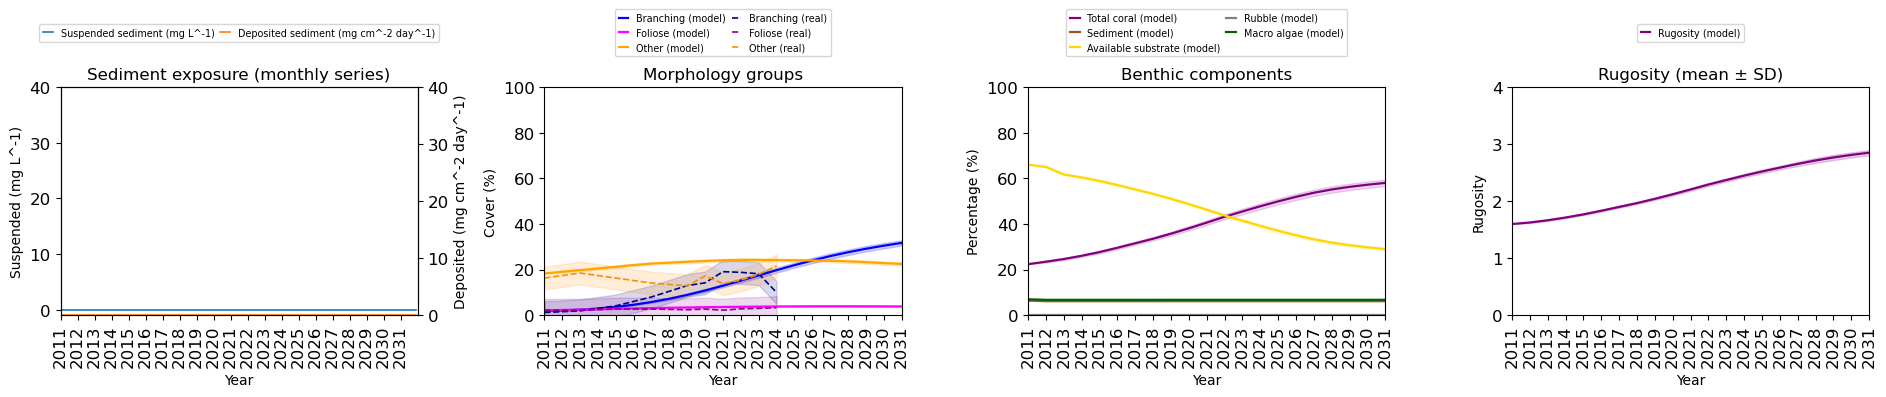

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

#
x = np.arange(2011, 2032)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))

ax.set_ylim(-1, 40)
ax2.set_ylim(0, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD + real (absolute ±5 cover)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

if isinstance(real_df, (list, tuple)) or hasattr(real_df, 'columns'):
    try:
        for col, color, lab in [
            ('RealBranching_Area (%)', 'darkblue', 'Branching (real)'),
            ('RealFoliose_Area (%)', 'darkmagenta', 'Foliose (real)'),
            ('RealOther_Area (%)',   'darkorange', 'Other (real)')
        ]:
            if real_df is not None and col in real_df.columns:
                yrs = real_df['Year'].astype(float).values
                vals = real_df[col].astype(float).values
                ax.plot(yrs, vals, color=color, linewidth=1.2, linestyle='--', label=lab)
                ax.fill_between(yrs, vals - 5.0, vals + 5.0, color=color, alpha=0.15)
    except Exception:
        pass

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD; compute total coral as sum(branching, foliose, other)
ax = axs[1, 2]
lines = []

# ensure arrays
_b = np.asarray(b_mean, dtype=float)
_bs = np.asarray(b_std, dtype=float)
_f = np.asarray(f_mean, dtype=float)
_fs = np.asarray(f_std, dtype=float)
_o = np.asarray(o_mean, dtype=float)
_os = np.asarray(o_std, dtype=float)

# total coral = branching + foliose + other; sd combined by sqrt(sum(var))
total_m = _b + _f + _o
total_s = np.sqrt(_bs**2 + _fs**2 + _os**2)

ln_total, = ax.plot(x, total_m, color='purple', linewidth=1.6, label='Total coral (model)')
ax.fill_between(x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ln_total)

ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_mac)

ax.set_ylim(0, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-4
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 4)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)

plt.show()


Saved output/figures\A1 Myrmidon base condition 25112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\A1 Myrmidon base condition 25112025_legend.png


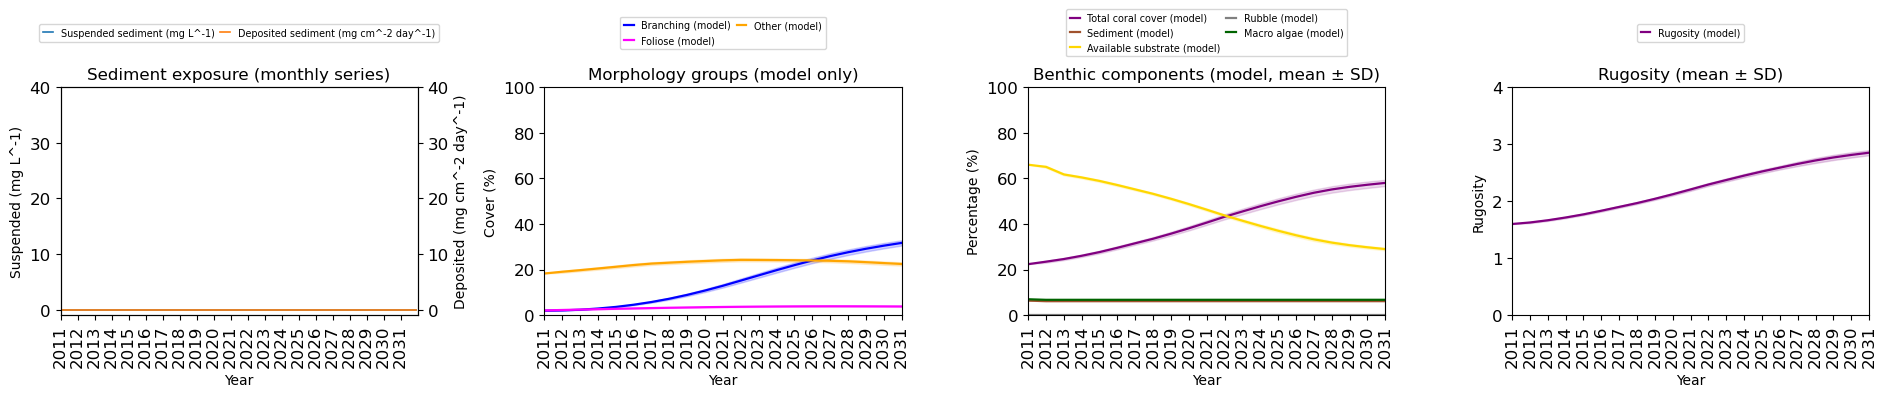

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

# x axis 2011-2031 (inclusive)
x = np.arange(2011, 2032)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)  # kept but not plotted

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))

ax.set_ylim(-1, 40)
ax2.set_ylim(-1, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD (model values only)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups (model only)')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD (plot standard deviation) and total coral cover computed from morphology
ax = axs[1, 2]

# ensure component arrays
branch_m = np.asarray(b_mean, dtype=float)
branch_s = np.asarray(b_std, dtype=float)
folio_m  = np.asarray(f_mean, dtype=float)
folio_s  = np.asarray(f_std, dtype=float)
other_m  = np.asarray(o_mean, dtype=float)
other_s  = np.asarray(o_std, dtype=float)

# compute total coral cover (use morphology groups rather than t_mean which may be incorrect)
total_mean = branch_m + folio_m + other_m
# assume independence and combine variances for std (sqrt(sum variances))
total_std = np.sqrt(branch_s**2 + folio_s**2 + other_s**2)

# Plot total coral cover (mean ± SD)
ln_total, = ax.plot(x, total_mean, color='purple', linewidth=1.6, label='Total coral cover (model)')
ax.fill_between(x, total_mean - total_std, total_mean + total_std, color='purple', alpha=0.15)

# Plot other benthic components with their SD
ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)

ax.set_ylim(0, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components (model, mean ± SD)')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-4
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 4)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)

plt.show()


In [9]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms